# Cross-over errors

This notebooks shows how to compute and analyze crossover errors between airborne flight lines.

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is downloaded and subset in the notebook `AGAP_magnetic_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "mag",
    ]
]

# for testing limit number of lines
data_df = data_df[~data_df.line.between(133, 142)]
data_df = data_df[~data_df.line.between(168, 176)]
data_df = data_df[
    (data_df.line.isin(data_df.line.unique()[::2])) | (data_df.line >= 143)
]

# define survey lines (0) vs tie lines (1)
data_df["line_type"] = np.where(data_df.line >= 142, 1, 0)

data_df.head()

,easting,northing,height,line,unixtime,distance_along_line,mag,line_type
0,621152.853769,159064.167598,4112.55,1,1.229500e+09,81.451091,-34.245,0
1,621367.339673,159092.051982,4119.45,1,1.229500e+09,297.742539,-37.740,0
2,621580.287957,159122.206492,4124.15,1,1.229500e+09,512.819231,-40.975,0
3,621766.100699,159150.747140,4127.50,1,1.229500e+09,700.811387,-43.430,0
4,621924.954435,159176.326498,4131.00,1,1.229500e+09,861.711758,-45.300,0


In [ ]:
survey = airbornegeo.Survey(
    data_df,
    line_column="line",
    distance_column="distance_along_line",
)
survey

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
ax = survey.plot(ax=ax, s=0.1)
airbornegeo.add_scalebar(ax, 100e3)

## Find intersections and interpolate their values
See previous notebooks for more details on these steps.

In [ ]:
# calculate theoretical intersection points
survey.create_intersection_table(method="groups")

# interpolate data values at intersections
survey.interpolate_intersections(
    to_interp="mag",
    window_width=1000,
    method="cubic",
    extrapolate=True,
)

# capture data_df and inters for use in downstream cells
data_df = survey.data
inters = survey.intersections

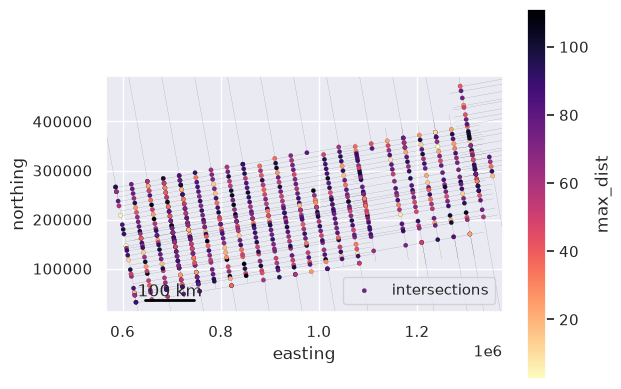

In [5]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    color="k",
    s=1,
    lw=0,
    marker=".",
    alpha=0.01,
)
inters.plot.scatter(
    "easting",
    "northing",
    c="max_dist",
    s=10,
    cmap="magma_r",
    marker="o",
    edgecolor="black",
    linewidth=0.1,
    ax=ax,
    label="intersections",
)
# zoom into region with intersections
reg = vd.get_region((inters.easting, inters.northing))
reg = vd.pad_region(reg, 20e3)
ax.set_xlim(reg[0], reg[1])
ax.set_ylim(reg[2], reg[3])

airbornegeo.add_scalebar(ax, 100e3)
ax.set_aspect("equal")

## Calculate intersection crossover errors
Now we have interpolated magnetic values for each intersecting line at the intersection points, we can calculate the cross-over errors for each intersection.

Running this function will add a new column to the intersections table 'crossover_error_0'. Everytime you rerun the function it will add a new column, incrementing the number (-> 'crossover_error_0'). However, if the crossover errors are identical to the last column (if nothing has changed), it will not add a new column. 

This error is always defined as `line1` - `line2`. Where `line1` and `line2` are defined in the intersections table.

Below we show a map of these crossover errors, and a histogram of their values.

In [ ]:
survey.calculate_crossover_errors(data_col="mag")
data_df = survey.data
inters = survey.intersections
inters.head()

In [ ]:
fig = survey.plotly_points(
    color="gray",
    hover_cols=["line"],
    size=1,
)
fig = airbornegeo.plotly_points(
    inters,
    fig=fig,
    color_col="crossover_error_0",
    hover_cols=["line1", "line2"],
    size=5,
    edge_width=1,
    cmap="balance",
    robust=True,
    absolute=True,
)

fig.show()

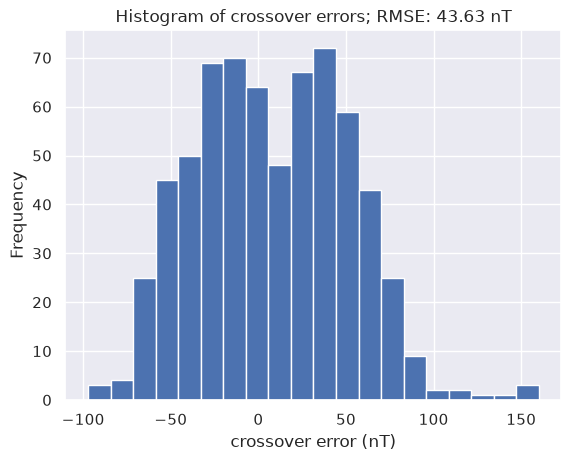

In [9]:
ax = inters.crossover_error_0.plot.hist(bins=20)
ax.set_xlabel("crossover error (nT)")
ax.set_title(
    f"Histogram of crossover errors; RMSE: {round(airbornegeo.rmse(inters.crossover_error_0), 2)} nT"
);

## Save results to use in the following notebooks

In [ ]:
survey.data.to_csv("data/AGAP_magnetic_survey_with_intersections.csv", index=None)
survey.intersections.to_csv("data/AGAP_magnetic_survey_intersections.csv", index=None)